In [1]:
import warnings; warnings.simplefilter('ignore')
import logging
logging.basicConfig(level=logging.INFO)
import sys
sys.path.append('..')
import torch
from pathlib import Path
import numpy as np
import librosa

from torch.nn import functional as F

import timm
import matplotlib.pyplot as plt

### Load an M2D model

For object centric masking.

In [2]:
from m2d.runtime_audio import RuntimeM2D
weight = 'm2d_vit_base-80x608p16x16-221006-mr7/checkpoint-300.pth'
model = RuntimeM2D(weight_file=weight, encoder_only=False)

Creating model: m2d_vit_base({'img_size': [80, 608], 'patch_size': [16, 16], 'decoder_depth': 8, 'norm_stats': [-7.1, 4.2]})
M2DViT(in_chans=1, patch size=(16, 16), grid_size=[ 5 38],
  embed_dim=768, depth=12, num_heads=12, decoder_embed_dim=512,
  decoder_depth=8, decoder_num_heads=16, mlp_ratio=4,
  norm_pix_loss=False, norm_stats=Parameter containing:
tensor([-7.1000,  4.2000]))
Set masking hint ratio to 1.0000.
+ loss_type=norm_mse, target_layers=None
 ClipLoss with rank=0, world_size=1


INFO:root:<All keys matched successfully>
INFO:root:<m2d.runtime_audio.Config object at 0x1535c5a8fa30>
INFO:root:Model input size: [80, 608]
INFO:root:Using weights: m2d_vit_base-80x608p16x16-221006-mr7/checkpoint-300.pth
INFO:root:training_mask: 0.0
INFO:root:flat_features: False
INFO:root:Runtime MelSpectrogram(16000, 400, 400, 160, 80, 50, 8000):
INFO:root:MelSpectrogram(
  Mel filter banks size = (80, 201), trainable_mel=False
  (stft): STFT(n_fft=400, Fourier Kernel size=(201, 1, 400), iSTFT=False, trainable=False)
)


 using 401 parameters from m2d_vit_base-80x608p16x16-221006-mr7/checkpoint-300.pth
 (included audio_proj params: []
 (included text_proj params: []
 (dropped: [] )
<All keys matched successfully>
 using norm_stats: -7.1, 4.2


In [3]:
from IPython.display import Audio, display

files = ['AudioSetWav16k/eval_segments/-22tna7KHzI_28.000.wav',
    'AudioSetWav16k/eval_segments/-0xzrMun0Rs_30.000.wav',
    'AudioSetWav16k/eval_segments/3tUlhM80ObM_0.000.wav',
    'AudioSetWav16k/eval_segments/-1nilez17Dg_30.000.wav',
    'AudioSetWav16k/eval_segments/--U7joUcTCo_0.000.wav',
    'AudioSetWav16k/eval_segments/5hlsVoxJPNI_30.000.wav',]
captions = ['The sound of Explosion.',
    'The sound of Stomach rumble, and Music.',
    'The sound of Knock.',
    'The sound of Heart murmur, and Speech.',
    "A man's laughter abruptly interrupts as someone sneezes, suggesting a casual gathering or social event.",
    "The sound of Christmas music, Music, and Speech.",]

wavs = [torch.tensor(librosa.load(f, sr=16000)[0]).unsqueeze(0) for f in files]
lmss = [model.to_normalized_spec(wav)[..., :608] for wav in wavs]

lms = lmss[5]

Audio(wavs[5].cpu().squeeze(), rate=16000)

In [4]:
from m2d.masking import *


def plot_bi_partition_masks(
    org_img,
    idx_mask: np.ndarray,
    alpha: float = 0.5,
    patch_size: int = (16, 16),
    target_size = (80, 608),
    grayscale = 0.5,
    origin = 'lower'
):
    grid_size = [target_size[0] // patch_size[0], target_size[1] // patch_size[1]]  # ex) [5, 38] for 80x608 with 16x16 patches

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    def apply_mask_and_plot(ax, idx_mask: np.ndarray, title_prefix: str):
        masked_img = org_img.copy()

        for idx in idx_mask:
            y = idx // grid_size[1]
            x = idx % grid_size[1]

            y_start, y_end = y * patch_size[0], (y + 1) * patch_size[0]
            x_start, x_end = x * patch_size[1], (x + 1) * patch_size[1]

            masked_img[y_start:y_end, x_start:x_end] = (1 - alpha) * org_img[y_start:y_end, x_start:x_end] + alpha * grayscale * np.ones(patch_size)

        ax.imshow(masked_img, origin=origin)
        ax.set_title(f"{title_prefix} (Set Size: {len(idx_mask)})", fontsize=12)
        ax.axis('off')

    apply_mask_and_plot(axes[0], idx_mask, title_prefix="Masked")
    ax = axes[1]
    ax.imshow(org_img, origin=origin)
    ax.set_title(f"Original LMS", fontsize=12)
    ax.axis('off')

    plt.tight_layout()
    plt.show()

### Object centric masking (SGIM)

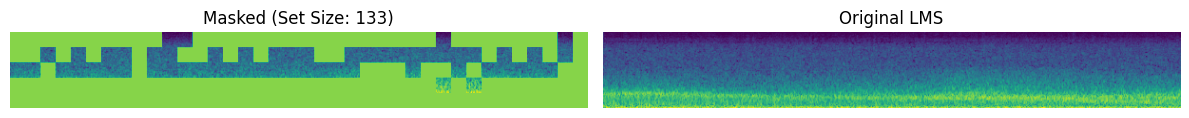

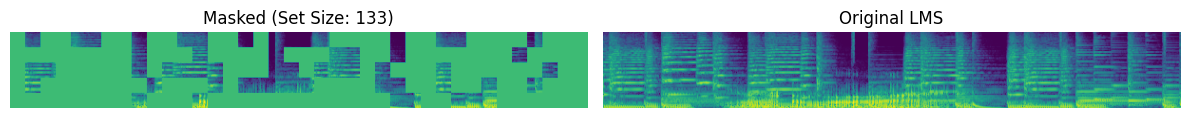

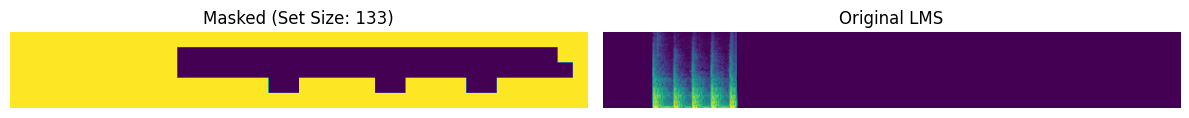

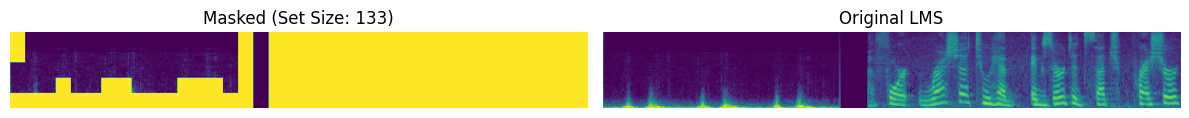

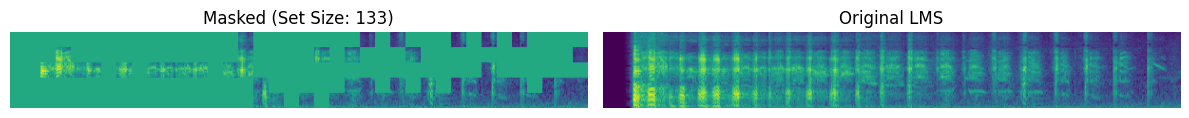

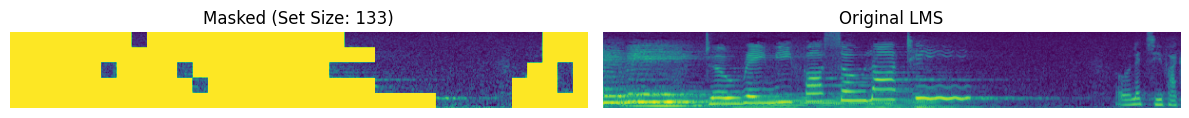

In [5]:
idx_masks, len_keep = object_centric_mask_with_hint(shape=None, mask_ratio=0.7, device='cpu', data=torch.vstack(lmss), patch_size=[16, 16],
                                                    hint_ratio=0.0, model=model.backbone)
for i, (l, idx_mask) in enumerate(zip(lmss, idx_masks)):
    plot_bi_partition_masks(l[0, 0].numpy(), idx_mask[len_keep:], alpha=1.)

### DWM variant -- deterministic

The masking results are very close to SGIM.

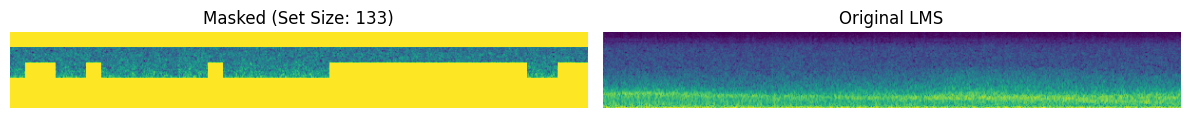

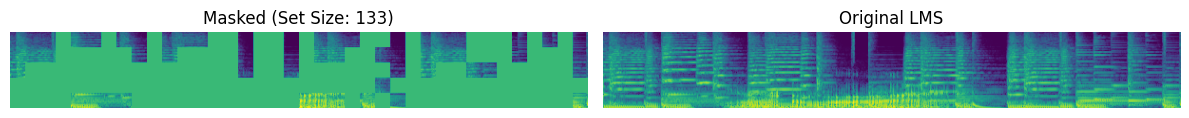

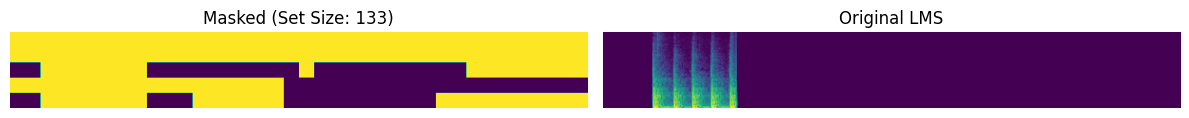

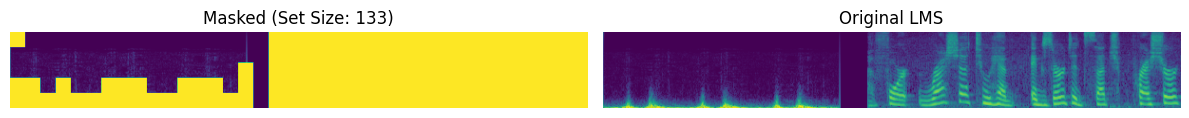

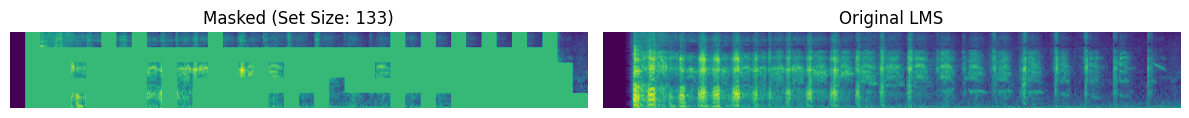

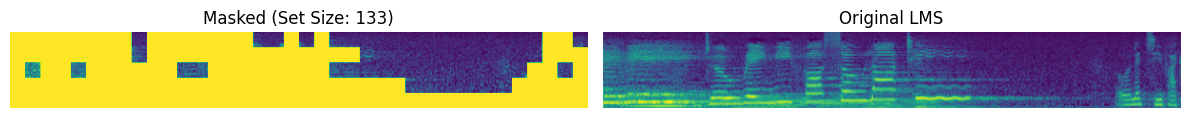

In [6]:
idx_masks, len_keep = random_weighted_mask_with_hint(shape=None, mask_ratio=0.7, device='cpu', data=torch.vstack(lmss), patch_size=[16, 16],
                                                    hint_ratio=0., probabilistic=False)
for i, (l, idx_mask) in enumerate(zip(lmss, idx_masks)):
    plot_bi_partition_masks(l[0, 0].numpy(), idx_mask[len_keep:], alpha=1.)

### DWM

Closer to SGIM, but still holds randomness.

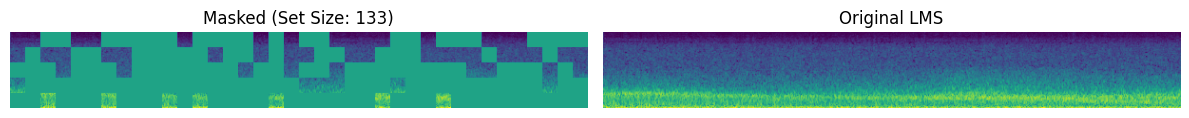

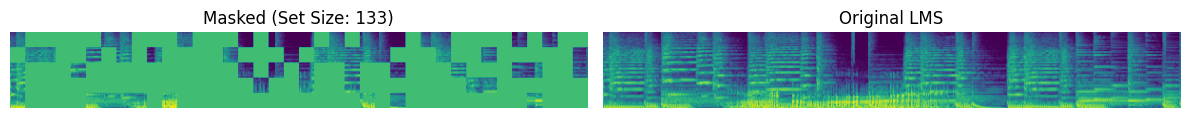

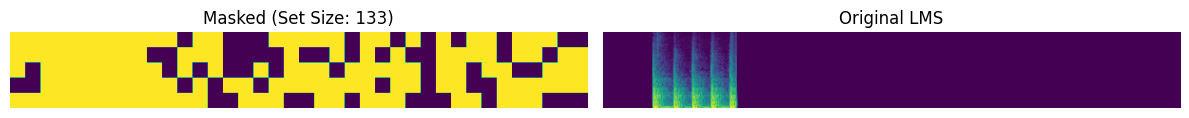

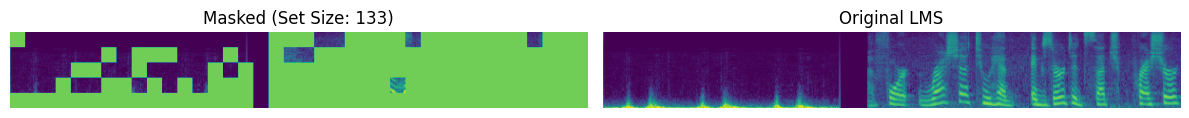

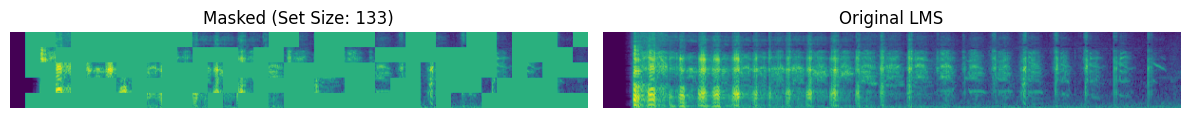

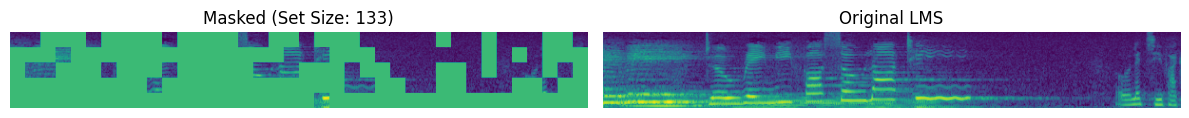

In [7]:
idx_masks, len_keep = random_weighted_mask_with_hint(shape=None, mask_ratio=0.7, device='cpu', data=torch.vstack(lmss), patch_size=[16, 16],
                                                    hint_ratio=0.)
for i, (l, idx_mask) in enumerate(zip(lmss, idx_masks)):
    plot_bi_partition_masks(l[0, 0].numpy(), idx_mask[len_keep:], alpha=1.)

### IBM

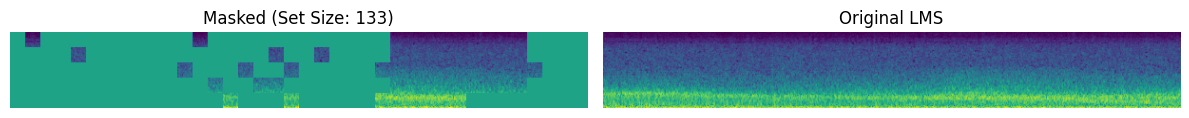

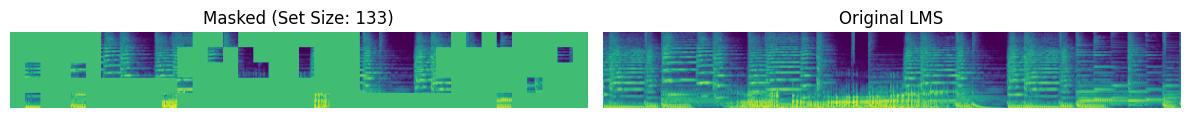

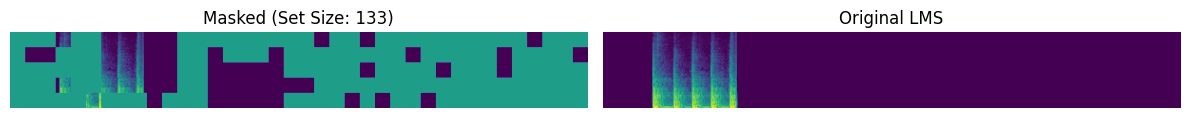

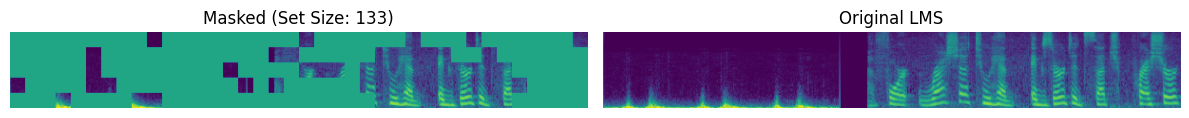

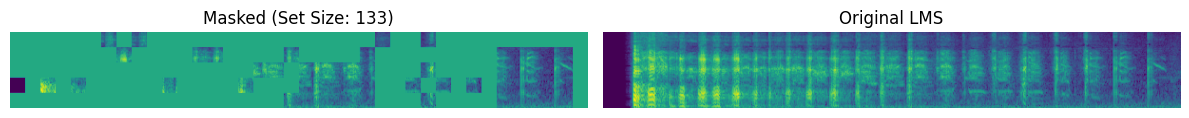

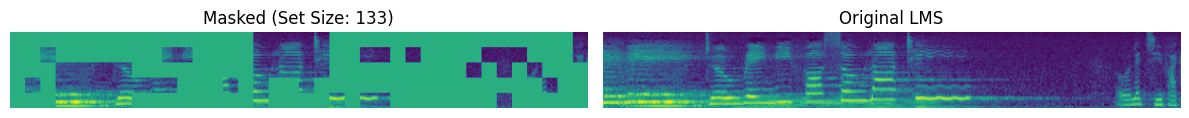

In [8]:
B, Nf, Nt = len(lmss), *model.backbone.grid_size()
idx_masks, len_keep = data2vec2_block_masking_wrapper(shape=[B, Nf, Nt], mask_ratio=0.7, device='cpu', hint_ratio=0.0)
for i, (l, idx_mask) in enumerate(zip(lmss, idx_masks)):
    plot_bi_partition_masks(l[0, 0].numpy(), idx_mask[len_keep:], alpha=1.)


### Paper figures

In [9]:
def plot_masks_stacked(
    org_img,
    idx_masks: np.ndarray,
    names: str,
    alpha: float = 0.5,
    patch_size: tuple = (16, 16),
    target_size: tuple = (80, 608),
    grayscale: float = 0.5,
    origin: str = 'lower',
    hspace: float = 0.0,
):
    N = len(idx_masks)
    total_rows = N + 1
    grid_size = [target_size[0] // patch_size[0], target_size[1] // patch_size[1]]
    
    v_min = org_img.min()
    v_max = org_img.max()

    aspect_ratio = target_size[1] / target_size[0]
    row_height = 1
    fig_width = int(row_height * aspect_ratio)
    fig, axes = plt.subplots(total_rows, 1, figsize=(fig_width, row_height * total_rows))
    
    if total_rows == 1: axes = [axes]

    imshow_kwargs = {
        'origin': origin,
        'vmin': v_min,
        'vmax': v_max,
        'cmap': 'viridis',
        'aspect': 'equal'
    }

    for i in range(total_rows):
        ax = axes[i]
        display_img = org_img.copy()

        if i > 0:
            idx_mask = idx_masks[i-1]
            overlay = np.full_like(org_img, grayscale)
            
            mask_map = np.zeros_like(org_img, dtype=bool)
            for idx in idx_mask:
                y, x = idx // grid_size[1], idx % grid_size[1]
                y_s, y_e = y * patch_size[0], (y + 1) * patch_size[0]
                x_s, x_e = x * patch_size[1], (x + 1) * patch_size[1]
                mask_map[y_s:y_e, x_s:x_e] = True
            
            display_img[mask_map] = (1 - alpha) * org_img[mask_map] + alpha * grayscale

        ax.imshow(display_img, **imshow_kwargs)
        ax.set_axis_off()
        ax.text(-0.01, 0.5, names[i], 
                transform=ax.transAxes, ha='right', va='center', fontsize=10, color='black')

    plt.subplots_adjust(left=0.11, right=1.0, top=1.0, bottom=0.0)
    plt.savefig('mask_samples.png', dpi=200, bbox_inches='tight')
    plt.show()

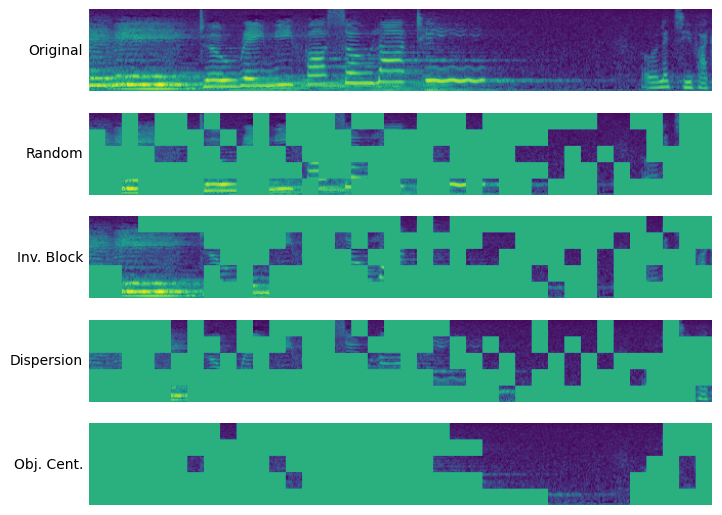

In [10]:
vis = [lmss[5]]*4
idx_masks, len_keep = random_unstructured_mask(shape=[len(vis), Nf, Nt], mask_ratio=0.7, device='cpu')
idx_masks_, len_keep = data2vec2_block_masking_wrapper(shape=[len(vis), Nf, Nt], mask_ratio=0.7, device='cpu', hint_ratio=0.0)
idx_masks[1] = idx_masks_[1]
idx_masks_, len_keep = random_weighted_mask_with_hint(shape=None, mask_ratio=0.7, device='cpu', data=torch.vstack(vis), patch_size=[16, 16],
                                                    hint_ratio=0.)
idx_masks[2] = idx_masks_[2]
idx_masks_, len_keep = object_centric_mask_with_hint(shape=None, mask_ratio=0.7, device='cpu', data=torch.vstack(vis), patch_size=[16, 16],
                                                    hint_ratio=0.0, model=model.backbone)
idx_masks[3] = idx_masks_[3]

plot_masks_stacked(l[0, 0].numpy(), idx_masks[:, len_keep:], ['Original', 'Random', 'Inv. Block', 'Dispersion', 'Obj. Cent.'], alpha=1.)

## Hint ratio $r_h$ schedules over training epochs for ablation settings.

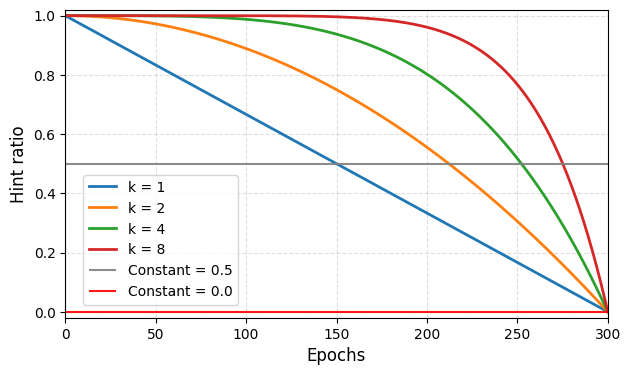

In [11]:
def f(t, k, total_epochs=300):
    return 1.0 - (t / total_epochs) ** k

t_values = np.linspace(0, 300, 500)
exponents = [1, 2, 4, 8]

plt.figure(figsize=(7, 4))

for k in exponents:
    y_values = f(t_values, k)
    label = f'k = {k}'
    plt.plot(t_values, y_values, label=label, linewidth=2)

plt.hlines(y=0.5, xmin=0, xmax=300, color='gray', linestyle='-', alpha=0.9, label='Constant = 0.5')
plt.hlines(y=0.0, xmin=0, xmax=300, color='red', linestyle='-', alpha=0.9, label='Constant = 0.0')

plt.xlim(0, 300)
plt.ylim(-0.02, 1.02)
#plt.title(r"Comparison of $1.0 - (t / 300)^k$ with various $k$", fontsize=14)
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Hint ratio", fontsize=12)
#plt.axhline(0, color='black', linewidth=0.5)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(loc='lower left', bbox_to_anchor=(0.02, 0.02), fontsize=10)
plt.savefig("hint_ratio_plot.svg", bbox_inches='tight')
plt.show()